In [59]:
#автоматическая перезагрузка измененных модулей
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Импорт библиотек и загрузка датасета

In [60]:
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display
from side_lib import *
from visual import *
from phik import phik_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor


pd.set_option('display.float_format', '{:,.2f}'.format) 

In [61]:
data = pd.read_csv('df_train.csv')

### 1. Препроцессинг.

In [62]:
#создаем копию для предобработки
df_preprocessed = data.copy()  

In [63]:
#изменим формат даты
df_preprocessed['date'] = pd.to_datetime(df_preprocessed['date'], format='%Y-%m-%d')

In [64]:
#выведем информацию о дубликатах
mis_dup_info(df_preprocessed)

,total,missing,percent_missing,duplicated,percent_duplicated
date,13603,0,0.0%,2,0.015%
price,13603,0,0.0%,2,0.015%
bedrooms,13603,0,0.0%,2,0.015%
grade,13603,0,0.0%,2,0.015%
has_basement,13603,0,0.0%,2,0.015%
living_in_m2,13603,0,0.0%,2,0.015%
renovated,13603,0,0.0%,2,0.015%
nice_view,13603,0,0.0%,2,0.015%
perfect_condition,13603,0,0.0%,2,0.015%
real_bathrooms,13603,0,0.0%,2,0.015%


Так как у нас всего 2 дубликата, можно удалить все дубликаты.

In [65]:
df_preprocessed = df_preprocessed.drop_duplicates().reset_index(drop=True)

Преобразуем булевы признаки в числовые для дальнейшего использования в моделях машинного обучения

In [66]:
#преобразуем булевы признаки в числовые
bool_cols = ['has_basement', 'nice_view', 'perfect_condition', 'has_lavatory', 'single_floor', 'renovated']
for col in bool_cols:
    df_preprocessed[col] = df_preprocessed[col].astype(int)


In [67]:
#выведем информацию о датафрейме после предобработки
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13601 entries, 0 to 13600
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               13601 non-null  datetime64[ns]
 1   price              13601 non-null  float64       
 2   bedrooms           13601 non-null  int64         
 3   grade              13601 non-null  int64         
 4   has_basement       13601 non-null  int64         
 5   living_in_m2       13601 non-null  float64       
 6   renovated          13601 non-null  int64         
 7   nice_view          13601 non-null  int64         
 8   perfect_condition  13601 non-null  int64         
 9   real_bathrooms     13601 non-null  int64         
 10  has_lavatory       13601 non-null  int64         
 11  single_floor       13601 non-null  int64         
 12  month              13601 non-null  int64         
 13  quartile_zone      13601 non-null  int64         
dtypes: dat

Разобьем данные на признаки и целевую переменную

In [68]:
#целевой признак
X = df_preprocessed.drop(columns=['price', 'date'])
y = df_preprocessed['price']

### 2. Подготовка Pipeline

In [69]:
pipelines = {
    #Линейная регрессия
    'LinearRegression': Pipeline([
        ('model', LinearRegression())
    ]),
    #Дерево решений
    'DecisionTree': Pipeline([
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
    #Случайный лес
    'RandomForest': Pipeline([
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    #LightGBM
    'LightGBM': Pipeline([
        ('model', LGBMRegressor(n_estimators=100, random_state=42))
    ])
}


In [70]:
#хранение результатов метрик
model_lr = pipelines['LinearRegression']
model_dt = pipelines['DecisionTree']
model_rf = pipelines['RandomForest']
model_gbm = pipelines['LightGBM']

### 3. Инициализация, и разбиение данных на Fold.

In [71]:
tscv = TimeSeriesSplit(n_splits=5)

#вывод индексов для каждого фолда
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    print(f'Fold {fold}:')
    print(f'Train: {train_index[0]}-{train_index[-1]}')
    print(f'Test:  {test_index[0]}-{test_index[-1]}')

Fold 0:
Train: 0-2270
Test:  2271-4536
Fold 1:
Train: 0-4536
Test:  4537-6802
Fold 2:
Train: 0-6802
Test:  6803-9068
Fold 3:
Train: 0-9068
Test:  9069-11334
Fold 4:
Train: 0-11334
Test:  11335-13600


Модель корректно разделяет данные

### 4. Машинное обучение.

Сделаем машинное обучение:
1. Линейная регрессия
2. Дерево решений
3. Случайный лес
4. LightGBM

Выведем:
1. Показатели качества моделей
2. Графики 


### 4.1. Линейная регрессия

,mean_mae,r2_mean,rmse_mean
LinearRegression,"78,318.72",0.74,"104,610.10"


,fold,mae,r2,rmse
0,0,"78,271.46",0.75,"103,536.36"
1,1,"76,827.80",0.74,"103,247.22"
2,2,"79,105.61",0.74,"106,501.76"
3,3,"79,046.58",0.75,"106,464.42"
4,4,"78,342.12",0.74,"103,300.74"


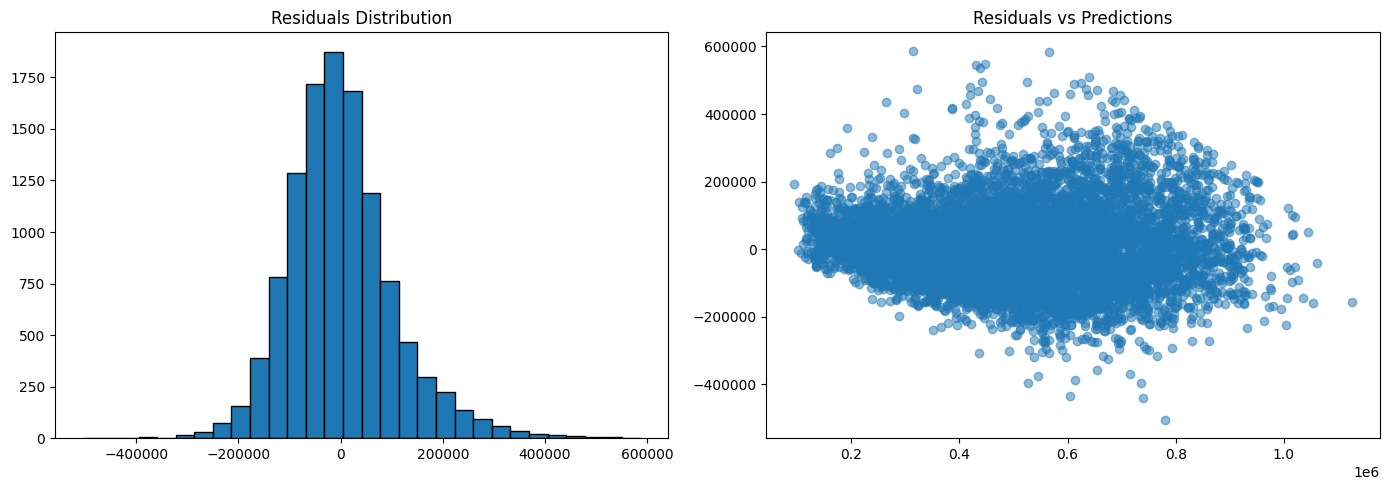

Feature importance недоступна для этой модели


In [72]:
df_res_lr_mean, df_res_lr_folds = evaluate_pipeline_to_df(
    "LinearRegression", pipelines['LinearRegression'], X, y, tscv
)

LinearRegression показала MAE ≈ 78k, RMSE ≈ 104k, R² ≈ 0.74, что говорит о достаточно хорошей линейной зависимости признаков и целевой переменной.
Остатки имеют нормальное распределение

### 4.2 Дерево Решений

,mean_mae,r2_mean,rmse_mean
DecisionTree,"105,547.81",0.51,"144,186.64"


,fold,mae,r2,rmse
0,0,"111,134.05",0.48,"149,303.12"
1,1,"102,476.80",0.52,"139,452.05"
2,2,"105,257.70",0.51,"146,016.70"
3,3,"104,045.99",0.54,"143,468.91"
4,4,"104,824.49",0.51,"142,692.40"


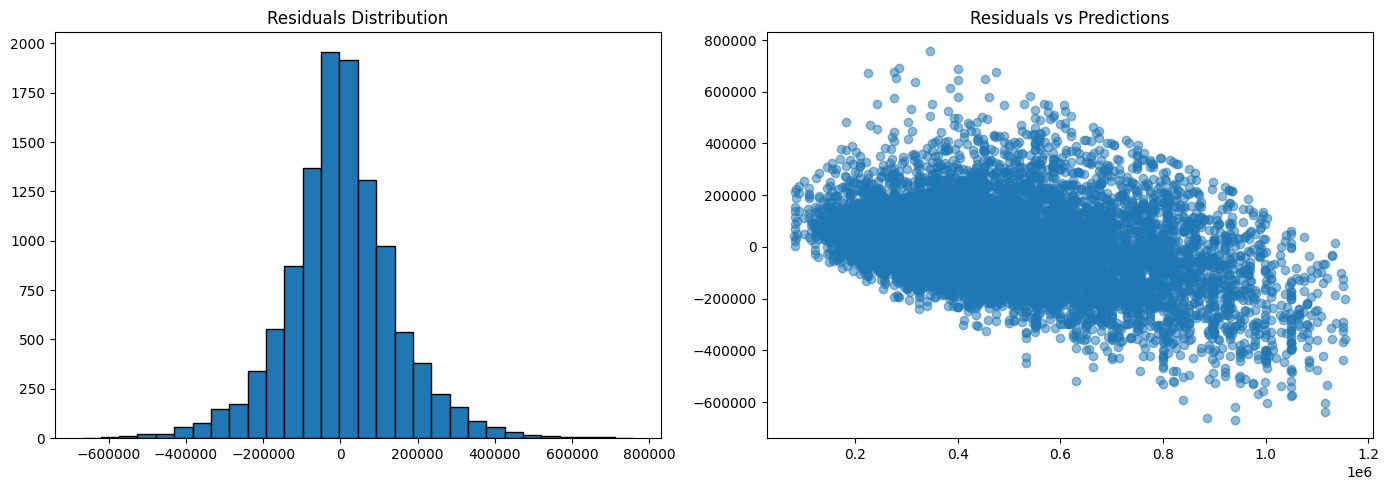

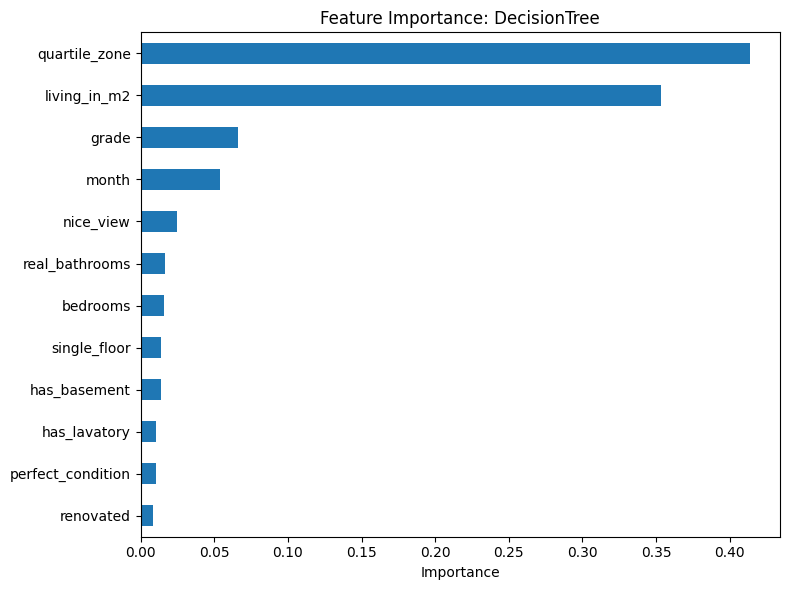

In [73]:
df_mean, df_folds = evaluate_pipeline_to_df(
    "DecisionTree",
    pipelines['DecisionTree'],
    X, y,
    tscv,
    plot_residuals=True
)

Слабые показатели, скорее всего произошло переобучение, и сказалось чувстиветьность одиночного дерева. в дальнейшем будет добавлять параметры max_depth и min_samples_split.  
Остатки имеют нормальное распределение, сильная важность quartile_zone и living_in_m2



### 4.3 Случайный лес

,mean_mae,r2_mean,rmse_mean
RandomForest,"78,087.14",0.73,"106,532.79"


,fold,mae,r2,rmse
0,0,"80,297.54",0.73,"108,359.43"
1,1,"77,031.69",0.72,"106,389.97"
2,2,"78,290.91",0.74,"106,688.74"
3,3,"76,859.25",0.75,"106,085.98"
4,4,"77,956.30",0.74,"105,139.86"


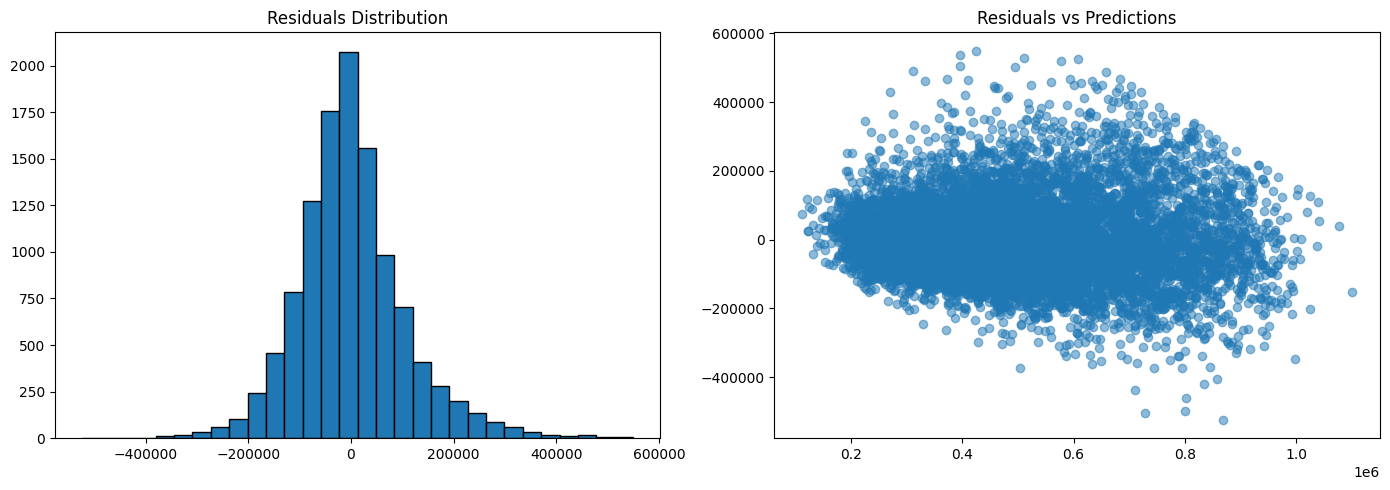

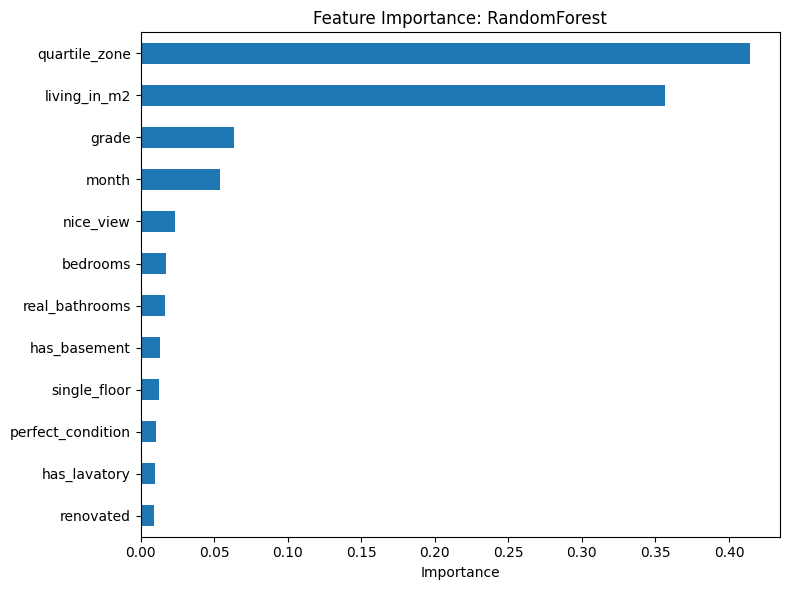

In [74]:
df_res_lr_mean, df_res_lr_folds = evaluate_pipeline_to_df(
    "RandomForest", pipelines['RandomForest'], X, y, tscv
)

RandomForest продемонстрировал стабильные результаты.  
RandomForest показал остатки без заметных трендов и выбросов, что говорит о более стабильном прогнозе, симметричный график.
Важнейшими здесь тоже показались quartile_zone и living_in_m2

### 4.4. Градиентный бустинг

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 2271, number of used features: 12
[LightGBM] [Info] Start training from score 476232.545575
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 4537, number of used features: 12
[LightGBM] [Info] Start training from score 476860.026449
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

,mean_mae,r2_mean,rmse_mean
LightGBM,"74,499.32",0.76,"101,763.94"


,fold,mae,r2,rmse
0,0,"76,957.23",0.75,"103,759.72"
1,1,"74,122.02",0.74,"102,083.84"
2,2,"74,600.08",0.76,"101,759.03"
3,3,"73,149.17",0.77,"101,489.35"
4,4,"73,668.11",0.76,"99,727.75"


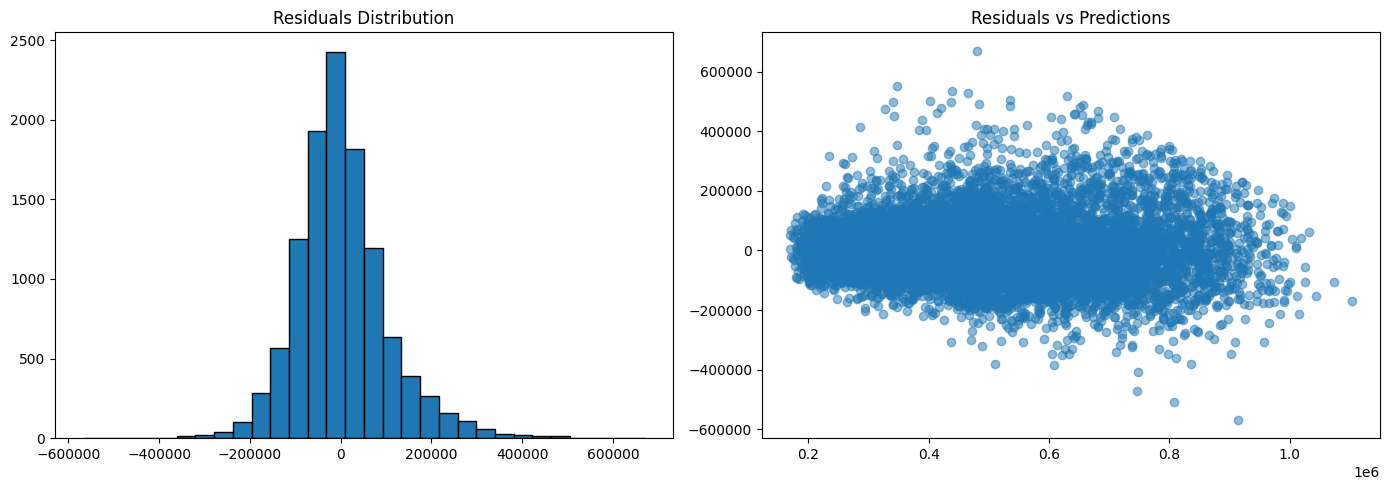

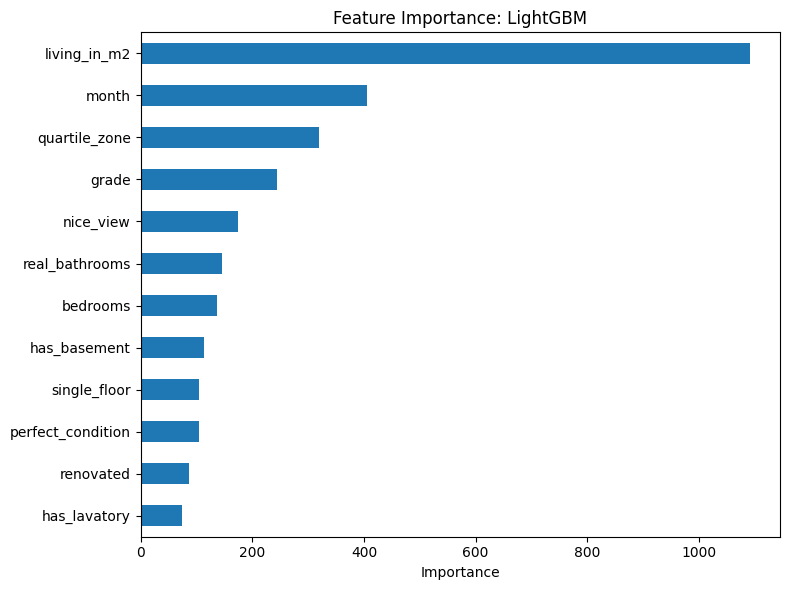

In [75]:
df_res_lr_mean, df_res_lr_folds = evaluate_pipeline_to_df(
    "LightGBM", pipelines['LightGBM'], X, y, tscv
)

Градиентный бустинг такой же стабильный, как и случайный лес, но работает быстрее, и так же использует другие feature importance метрики для оценки важности признаков. так же имеет симметричное распределение.

### 5. Проверка влияния удаления признаков с большим importance

#### 5.1 Случайный лес

In [76]:
#анализируем влияние признаков
X_no_q = X.drop(columns=["quartile_zone"])
df_res_lr_mean, df_res_lr_folds = evaluate_pipeline_to_df(
    "RandomForest", pipelines['RandomForest'], X_no_q, y, tscv,
    plot_residuals=False,
    plot_feature_importance=False
)

X_no_q = X.drop(columns=["living_in_m2"])
df_res_lr_mean, df_res_lr_folds = evaluate_pipeline_to_df(
    "RandomForest", pipelines['RandomForest'], X_no_q, y, tscv,
    plot_residuals=False,
    plot_feature_importance=False
)


,mean_mae,r2_mean,rmse_mean
RandomForest,"119,625.50",0.45,"153,468.05"


,fold,mae,r2,rmse
0,0,"120,582.62",0.46,"153,230.05"
1,1,"117,438.81",0.44,"150,655.20"
2,2,"120,444.02",0.44,"155,141.30"
3,3,"120,787.86",0.45,"156,709.14"
4,4,"118,874.19",0.45,"151,604.57"


,mean_mae,r2_mean,rmse_mean
RandomForest,"86,903.45",0.67,"117,765.38"


,fold,mae,r2,rmse
0,0,"88,126.31",0.68,"118,309.74"
1,1,"86,837.14",0.66,"116,953.83"
2,2,"86,794.57",0.68,"117,792.78"
3,3,"85,973.95",0.68,"118,817.84"
4,4,"86,785.28",0.67,"116,952.73"


Влияние Importance не пустое, а настоящее

#### 5.2 Линейная регрессия

In [77]:
#анализируем влияние признаков
X_no_q = X.drop(columns=["quartile_zone"])
df_res_lr_mean, df_res_lr_folds = evaluate_pipeline_to_df(
    "LinearRegression", pipelines['LinearRegression'], X_no_q, y, tscv,
    plot_residuals=False,
    plot_feature_importance=False
)

X_no_q = X.drop(columns=["living_in_m2"])
df_res_lr_mean, df_res_lr_folds = evaluate_pipeline_to_df(
    "LinearRegression", pipelines['LinearRegression'], X_no_q, y, tscv,
    plot_residuals=False,
    plot_feature_importance=False
)


,mean_mae,r2_mean,rmse_mean
LinearRegression,"114,097.88",0.51,"145,046.70"


,fold,mae,r2,rmse
0,0,"112,725.35",0.53,"142,766.12"
1,1,"113,125.06",0.50,"142,728.96"
2,2,"115,839.16",0.50,"147,185.00"
3,3,"116,506.70",0.50,"149,904.75"
4,4,"112,293.12",0.51,"142,648.69"


,mean_mae,r2_mean,rmse_mean
LinearRegression,"84,716.38",0.70,"112,640.98"


,fold,mae,r2,rmse
0,0,"84,475.83",0.71,"111,291.22"
1,1,"82,800.47",0.70,"110,448.81"
2,2,"84,851.06",0.70,"113,363.99"
3,3,"85,750.98",0.70,"115,636.55"
4,4,"85,703.57",0.70,"112,464.31"


Тут так же, влияние importance влияет на предсказание

### 6. Показатели по всем моделям

In [84]:
#создаём пустой DataFrame для mean-метрик
df_final_comp = pd.DataFrame()

#список моделей
models = ["LinearRegression", "DecisionTree", "RandomForest", "LightGBM"]

for name in models:
    df_mean, _ = evaluate_pipeline_to_df(
        name, pipelines[name], X, y, tscv,
        plot_residuals=False,
        plot_feature_importance=False,
        show_folds=False
    )
    #добавляем только mean-метрики
    df_final_comp = pd.concat([df_final_comp, df_mean])

#итоговая таблица
df_final_comp

,mean_mae,r2_mean,rmse_mean
LinearRegression,"78,318.72",0.74,"104,610.10"


,mean_mae,r2_mean,rmse_mean
DecisionTree,"105,547.81",0.51,"144,186.64"


,mean_mae,r2_mean,rmse_mean
RandomForest,"78,087.14",0.73,"106,532.79"


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 2271, number of used features: 12
[LightGBM] [Info] Start training from score 476232.545575
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 4537, number of used features: 12
[LightGBM] [Info] Start training from score 476860.026449
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

,mean_mae,r2_mean,rmse_mean
LightGBM,"74,499.32",0.76,"101,763.94"


,mean_mae,r2_mean,rmse_mean
LinearRegression,"78,318.72",0.74,"104,610.10"
DecisionTree,"105,547.81",0.51,"144,186.64"
RandomForest,"78,087.14",0.73,"106,532.79"
LightGBM,"74,499.32",0.76,"101,763.94"


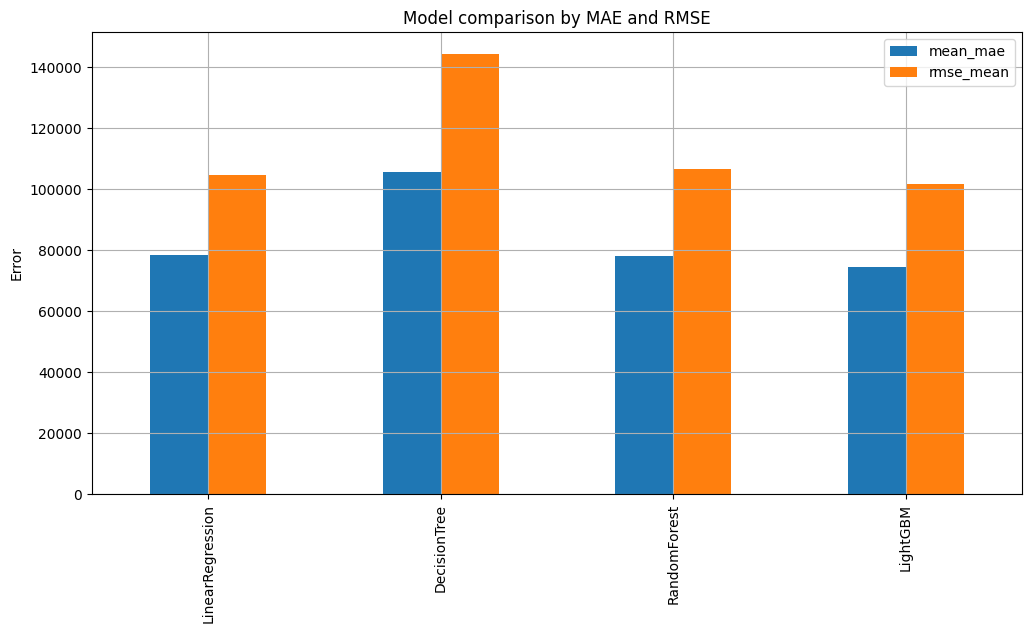

In [85]:
df_final_comp.plot(
    y=['mean_mae', 'rmse_mean'],
    kind='bar',
    figsize=(12, 6),
    grid=True,
    title='Model comparison by MAE and RMSE'
)
plt.ylabel('Error')
plt.show()


Все модели кроме Дерева решений имеют примерно одинаковые метрики, более точные прогнозы дал LightGBM